# Visualisation des fichiers .pt
Notebook pour inspecter les jeux d'entraînement/test produits par data_mining.py (format MNIST compatible).

In [31]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

In [32]:
# Paths (ajuster si besoin)
DATA_ROOT = "../data/RT28"  # ou data/MNIST
TRAIN_PT = os.path.join(DATA_ROOT, "processed", "training.pt")
TEST_PT = os.path.join(DATA_ROOT, "processed", "test.pt")

In [42]:
def load_pt_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    loaded = torch.load(path)
    return loaded

train_images = load_pt_dataset(TRAIN_PT)
test_images = load_pt_dataset(TEST_PT)

print("Train images", train_images.shape, train_images.dtype)
print("Test images", test_images.shape, test_images.dtype)

Train images torch.Size([1300, 28, 28]) torch.uint8
Test images torch.Size([145, 28, 28]) torch.uint8


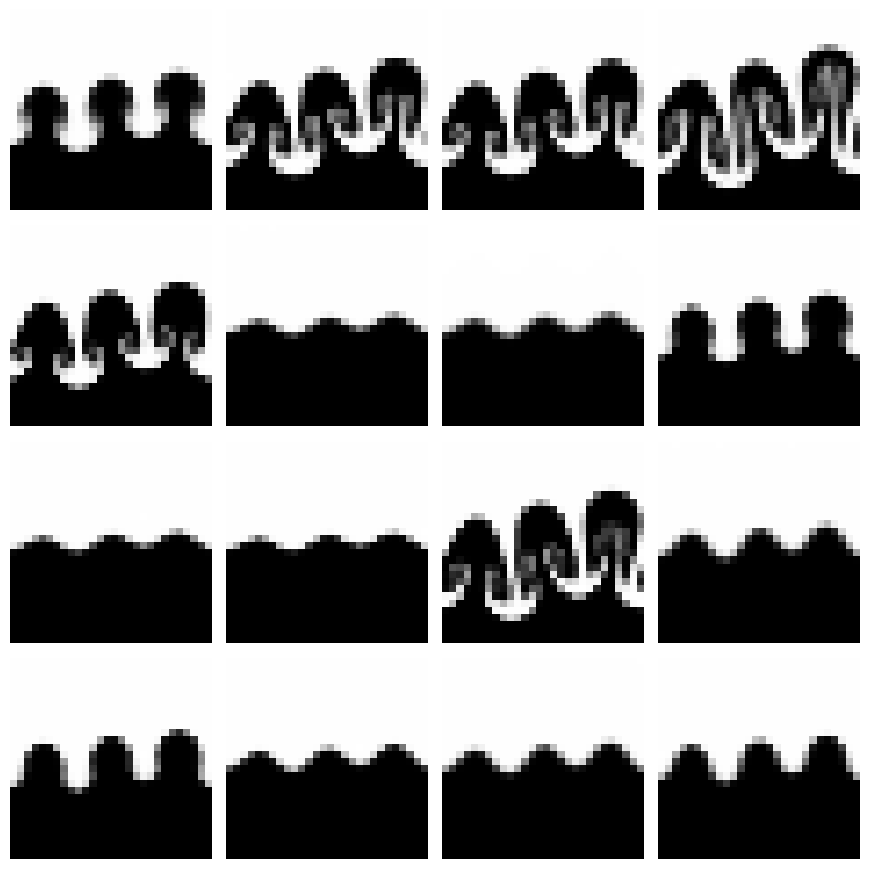

In [44]:
def show_grid(images, n=16, cols=4, cmap="gray"):
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 2.2, rows * 2.2))
    for i in range(n):
        ax = plt.subplot(rows, cols, i + 1)
        img = images[i].numpy() if torch.is_tensor(images) else images[i]
        ax.imshow(img, cmap=cmap)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_grid(train_images, n=16, cols=4)

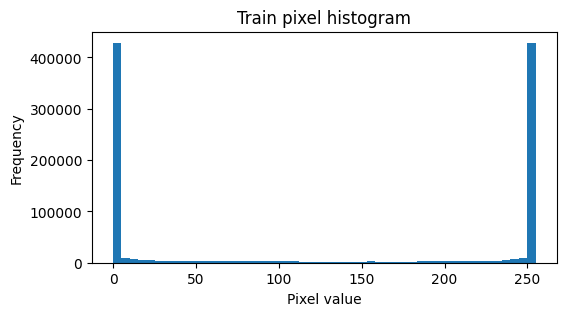

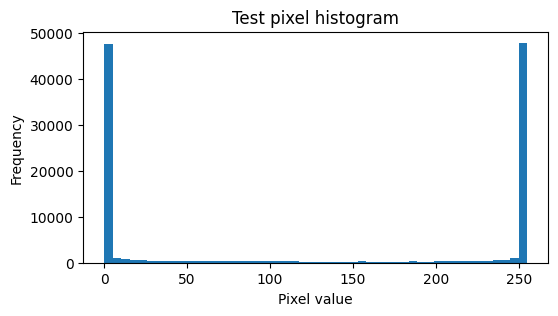

In [45]:
def plot_value_stats(images, title):
    img_np = images.numpy() if torch.is_tensor(images) else images
    plt.figure(figsize=(6, 3))
    plt.hist(img_np.flatten(), bins=50)
    plt.title(title)
    plt.xlabel("Pixel value")
    plt.ylabel("Frequency")
    plt.show()

plot_value_stats(train_images, "Train pixel histogram")
plot_value_stats(test_images, "Test pixel histogram")